In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gamma

# 📝 과제 : 연속형 데이터의 평균 추정
MLE와 MAP 2가지 방법으로 평균을 추정하고 그 결과 비교하기


In [2]:
# 데이터 준비
np.random.seed(42)
true_mean = 30  # 실제 평균
true_std = 5   # 실제 표준편차
n_samples = 500  # 데이터 개수

# 평균이 50이고 표준 편차가 10인 정규 분포에서 생성된 연속형 데이터
data = np.random.normal(loc=true_mean, scale=true_std, size=n_samples)

Data Summary:
Total samples: 500
Mean: 30.03
Standard deviation: 4.90


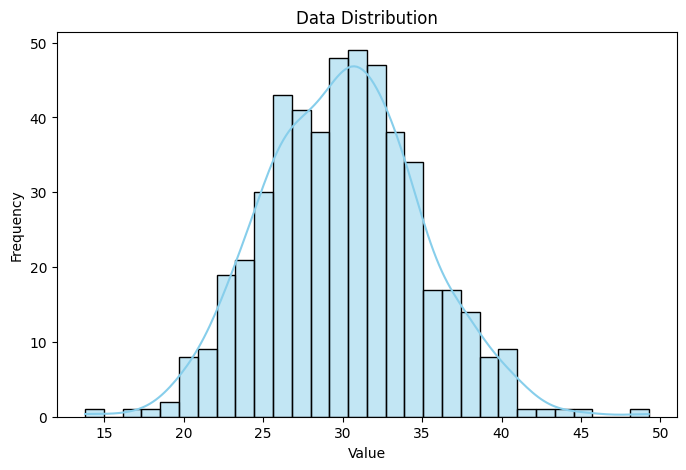

In [3]:
# 데이터 분포 확인
def eda(data):
    print("Data Summary:")
    print(f"Total samples: {len(data)}")
    print(f"Mean: {np.mean(data):.2f}")
    print(f"Standard deviation: {np.std(data):.2f}")

    # Data Visualization
    plt.figure(figsize=(8, 5))
    sns.histplot(data, kde=True, color="skyblue", bins=30)
    plt.title("Data Distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

eda(data)

### MLE
### 1. 우도 계산  
우도 함수는 주어진 파라미터 𝜇 하에서 관측될 확률의 곱으로 정의.  
  
정규분포 𝑁(𝜇,𝜎^2)를 가정했을 때, 각 데이터 𝑥_𝑖의 PDF는  

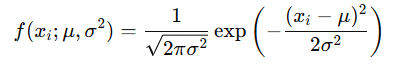
  
데이터의 독립성을 만족한다는 전제 하에 전체 데이터 𝑥_1,𝑥_2,…,𝑥_𝑛에 대한 우도 함수는  
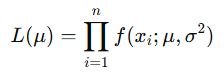
  
---  

### 2. 로그 우도 함수 미분
정규분포의 우도 함수에 로그를 취하면  
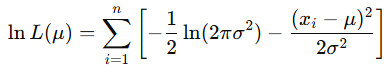
  
상수인 −(1/2)ln(2𝜋𝜎^2)는 𝜇에 영향을 주지 않으므로 생략하고, ln𝐿(𝜇)는 다음과 같이 단순화  
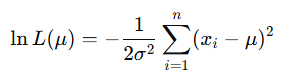  

μ에 대해 미분하면

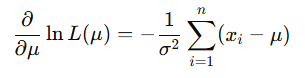  
  
---  
  
### 3. 미분식에서 μ계산
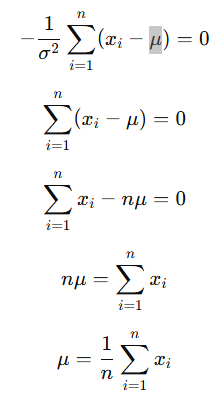

In [4]:
# MLE 함수
# 문제 1: 위의 정규분포 MLE 과정을 읽고 아래 빈칸을 채워주세요.
def mle_estimation(data):

    data_sum = np.sum(data)  # 데이터 합
    n_samples = len(data)    # 데이터 개수

    mle_mean = data_sum / n_samples

    return mle_mean

## MAP

### 1. 사전분포 정의
μ가 정규분포를 따른다고 가정

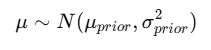  

---  
  
### 2. 우도 계산
주어진 데이터 𝑥_1,𝑥_2,…,𝑥_𝑛가 정규분포를 따르기 때문에 우도 함수는 아래와 같이 정의  

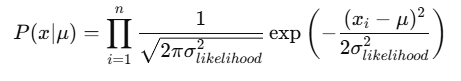  
  
---  
  
### 3, 사후 분포 계산
베이즈 정리에 따라 사후 확률은 다음과 같이 정의  

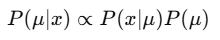  

사전 분포와 우도 함수가 모두 정규분포인 정규 사후 분포 역시 정규 분포가 됨  

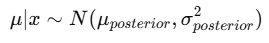  

이때 사후 평균의 정의는  

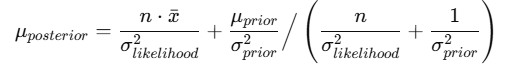  

여기서
- 𝑛: 데이터 개수
- xˉ: 데이터의 평균
- σ_likelihood^2: 우도의 분산
- σ_prior^2: 사전의 분산
- μ_prior: 사전 평균

In [5]:
# MAP 함수
# 문제 2: 위의 정규분포 MAP 과정을 읽고 아래 빈칸을 채워주세요.
def map_estimation(data, mu_prior, sigma_prior, sigma_likelihood):

    # 사전 확률의 평균과 분산
    prior_variance = sigma_prior**2
    # 우도 분산
    likelihood_variance = sigma_likelihood**2

    # 사후 확률 계산
    n_samples = len(data)        # 데이터 개수
    sample_mean = np.mean(data)  # 데이터 평균

    # 사후 확률의 평균 정의
    posterior_mean = ((likelihood_variance * n_samples * sample_mean) + (prior_variance * mu_prior)) / \
                     ((n_samples * likelihood_variance) + prior_variance)

    return posterior_mean

# 사전확률 정의
mu_prior = 25  # 평균
sigma_prior = 2  # 표준편차

sigma_likelihood = true_std  # 우도 표준편차는 데이터의 표준편차

In [6]:
# 추정 결과
mle_result = mle_estimation(data)
map_result = map_estimation(data, mu_prior, sigma_prior, sigma_likelihood)

print("MLE Estimate for Mean:", mle_result)
print("MAP Estimate for Mean:", map_result)

MLE Estimate for Mean: 30.03418997294324
MAP Estimate for Mean: 30.032579547488044


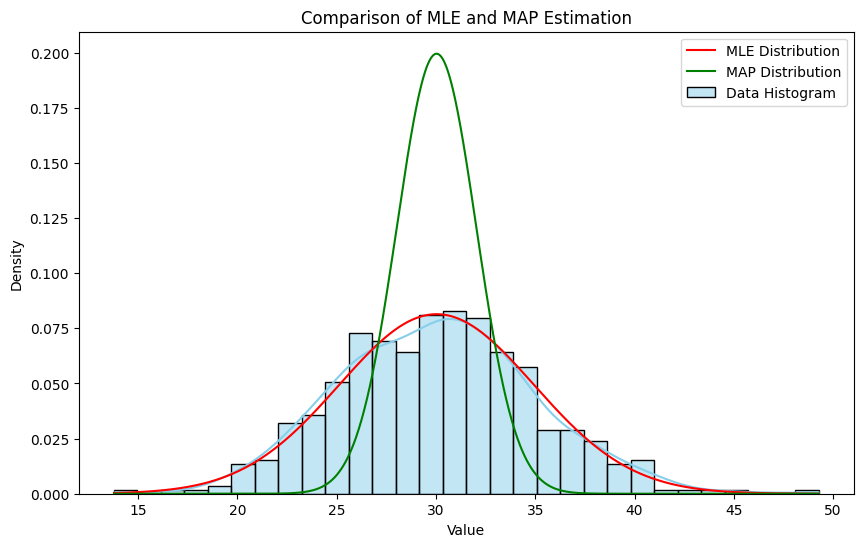

In [7]:
# 시각화
x = np.linspace(min(data), max(data), 1000)
sample_std = np.std(data)
mle_pdf = (1 / (np.sqrt(2 * np.pi) * sample_std)) * np.exp(-0.5 * ((x - mle_result) / sample_std)**2)
map_pdf = (1 / (np.sqrt(2 * np.pi) * sigma_prior)) * np.exp(-0.5 * ((x - map_result) / sigma_prior)**2)

plt.figure(figsize=(10, 6))
sns.histplot(data, kde=True, color="skyblue", bins=30, label="Data Histogram", stat="density")
plt.plot(x, mle_pdf, label="MLE Distribution", color="red")
plt.plot(x, map_pdf, label="MAP Distribution", color="green")
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Comparison of MLE and MAP Estimation")
plt.legend()
plt.show()

## 문제 3: 두 가지 추정 방법의 결과에 대해 MLE와 MAP를 비교하고, 차이가 발생했다면 그 이유를 서술하세요.  
(힌트: MLE와 MAP의 과정 차이)

In [ ]:
MLE와 MAP의 평균 추정치는 거의 같지만, 두 방법의 차이는 사전 정보를 고려하는지 여부에서 발생한다. MLE는 데이터만을 기반으로 평균을 추정하는 방법으로, 단순한 샘플 평균을 계산하여 최적의 값을 찾는다. 반면, MAP은 사전 정보를 반영하여 평균을 추정하는 방법으로, 베이즈 정리를 적용하여 사전 분포와 데이터 우도를 함께 고려한다.  

이번 실험에서는 데이터 개수(n)가 충분히 많고, 사전 평균(μ_prior = 25)이 데이터 평균(30)과 큰 차이가 없었기 때문에, MAP과 MLE의 결과가 거의 동일하게 나왔다. 하지만, 데이터가 적거나 사전 평균이 극단적으로 다르면 MAP과 MLE의 차이가 커질 수 있다. 즉, MAP은 사전 정보의 영향을 받지만, 데이터가 충분할 경우 MLE와 거의 같은 결과를 낸다.